In [108]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import signal
from scipy.signal import lfilter
from sklearn.preprocessing import StandardScaler, MinMaxScaler



In [109]:
files = {
    'music': r".\\lesson40_data\\One_Republic_-_Counting_stars_(SkySound.cc).mp3",
    'text': r".\\lesson40_data\\text.mp3",
    'city': r".\\lesson40_data\\zvuk-ulicy.mp3",
    'bird': r".\\lesson40_data\\bird.mp3",
    'sna': r".\\lesson40_data\\andez-s-o-s-shadow_the-white-stripes-seven-nation-army.mp3"
}

## Класс AudioAnalyzer

Единый класс для всех методов анализа аудио-сигналов.

In [110]:
class AudioAnalyzer:
    def __init__(self, audio_path, sr=22050, duration=60):
        self.audio_path = audio_path
        self.sr = sr
        self.duration = duration
        self.y, self.sr = librosa.load(audio_path, sr=sr, duration=duration)
        
    def get_fft(self):
        fft_spectrum = np.fft.fft(self.y)
        magnitude = np.abs(fft_spectrum)
        freqs = np.fft.fftfreq(len(self.y), 1/self.sr)
        half_n = len(magnitude) // 2
        return {
            'magnitude': magnitude[:half_n],
            'freqs': freqs[:half_n],
            'peak_freq': freqs[np.argmax(magnitude[:half_n])]
        }
    
    def get_spectral_features(self):
        centroid = librosa.feature.spectral_centroid(y=self.y, sr=self.sr)[0]
        bandwidth = librosa.feature.spectral_bandwidth(y=self.y, sr=self.sr)[0]
        return {
            'centroid': centroid,
            'bandwidth': bandwidth,
            'centroid_mean': np.mean(centroid),
            'bandwidth_mean': np.mean(bandwidth)
        }
    
    def get_rms(self):
        rms = librosa.feature.rms(y=self.y)[0]
        return {
            'rms': rms,
            'rms_mean': np.mean(rms),
            'rms_std': np.std(rms)
        }
    
    def get_zcr(self):
        zcr = librosa.feature.zero_crossing_rate(self.y)[0]
        return {
            'zcr': zcr,
            'zcr_mean': np.mean(zcr),
            'zcr_std': np.std(zcr)
        }
    
    def get_hpss(self):
        harmonic, percussive = librosa.effects.hpss(self.y)
        return {
            'harmonic': harmonic,
            'percussive': percussive,
            'harmonic_energy': np.sum(harmonic**2),
            'percussive_energy': np.sum(percussive**2)
        }
    
    def get_mfcc(self, n_mfcc=13):
        mfccs = librosa.feature.mfcc(y=self.y, sr=self.sr, n_mfcc=n_mfcc)
        return {
            'mfccs': mfccs,
            'mean': np.mean(mfccs, axis=1),
            'std': np.std(mfccs, axis=1)
        }
    
    def get_chroma(self):
        chroma = librosa.feature.chroma_stft(y=self.y, sr=self.sr)
        return {
            'chroma': chroma,
            'chroma_mean': np.mean(chroma, axis=1)
        }
    
    def get_spectral_contrast(self, n_bands=6):
        contrast = librosa.feature.spectral_contrast(y=self.y, sr=self.sr, n_bands=n_bands)
        return {
            'contrast': contrast,
            'contrast_mean': np.mean(contrast, axis=1)
        }

    
    def get_lpc(self, order=16):
        a = librosa.lpc(self.y, order=order)
        return {
            'coefficients': a,
            'order': order
        }




## 1. Fast Fourier Transform (FFT)

**Теория:** Преобразование Фурье разлагает временной сигнал на частотные компоненты.

**Формула:**

$$X_k = \sum_{n=0}^{N-1} x_n e^{-i \frac{2\pi}{N} kn}$$

где $x_n$ — отсчеты сигнала, $X_k$ — спектральные коэффициенты, $N$ — длина сигнала

In [111]:
fft_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    fft_results[name] = analyzer.get_fft()
    print(f"{name}: Peak = {fft_results[name]['peak_freq']:.2f} Hz")

music: Peak = 42.70 Hz
text: Peak = 182.43 Hz
city: Peak = 30.14 Hz
bird: Peak = 2575.97 Hz
sna: Peak = 65.67 Hz


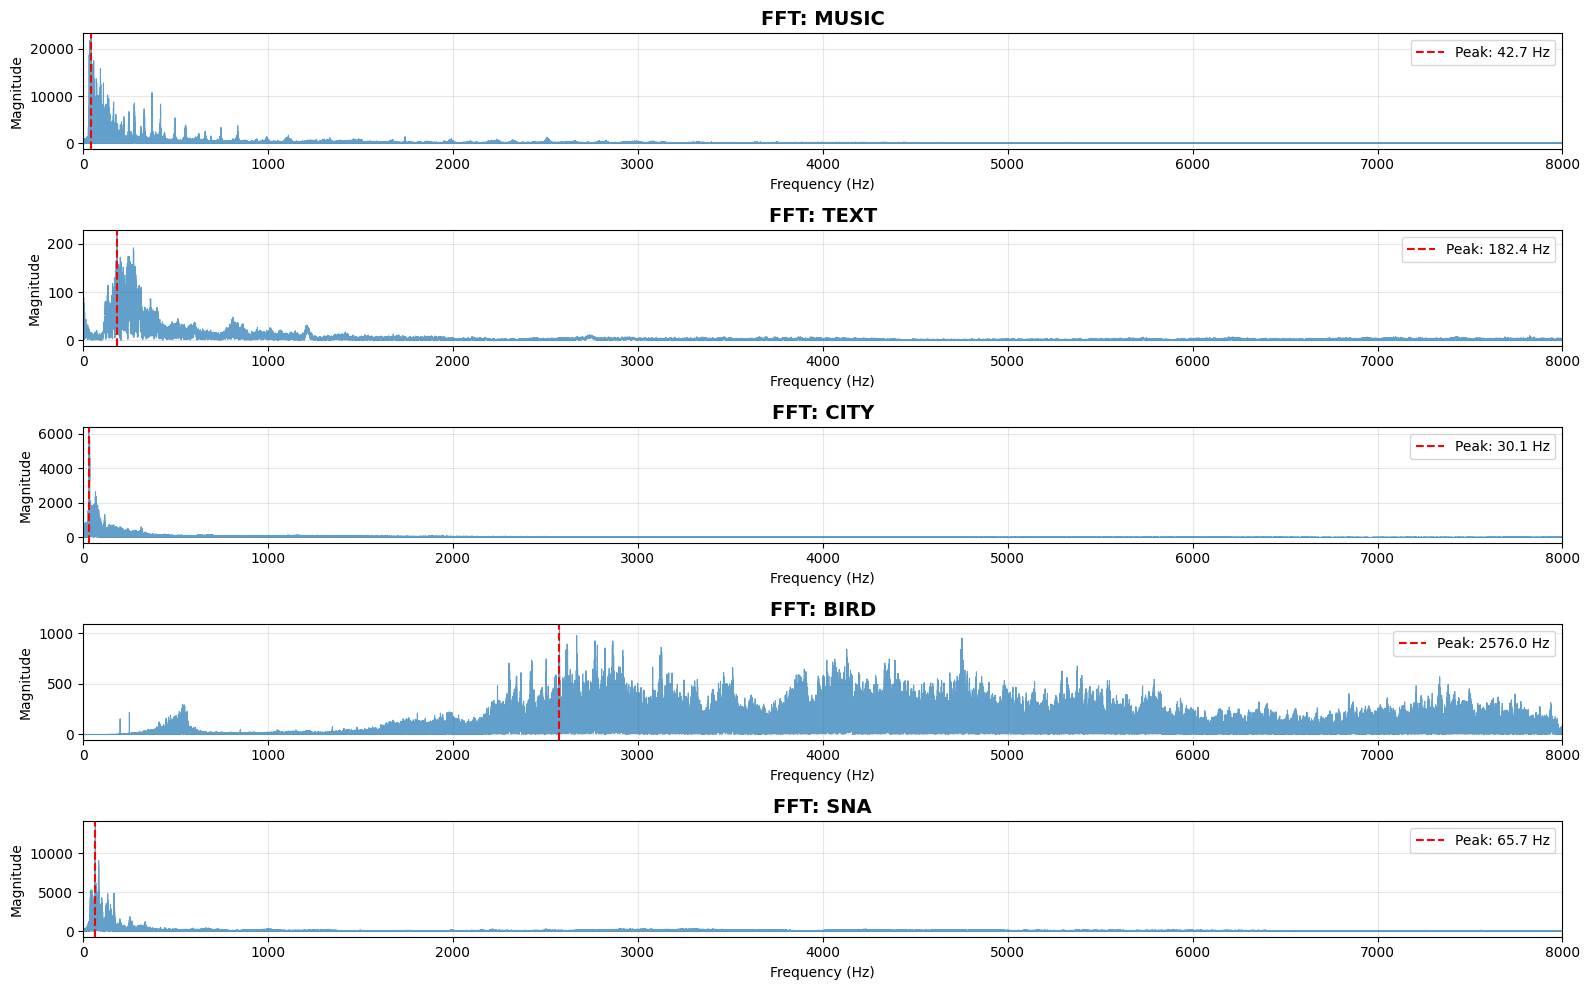

In [112]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, data) in enumerate(fft_results.items()):
    ax = axes[idx]
    ax.plot(data['freqs'], data['magnitude'], alpha=0.7, linewidth=0.8)
    ax.set_title(f'FFT: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    ax.set_xlim(0, 8000)
    ax.grid(True, alpha=0.3)
    ax.axvline(data['peak_freq'], color='red', linestyle='--', label=f"Peak: {data['peak_freq']:.1f} Hz")
    ax.legend()
plt.tight_layout()


## 2. Spectral Centroid & Bandwidth

**Теория:**
- **Spectral Centroid** — "центр масс" спектра
- **Spectral Bandwidth** — ширина спектра

**Формулы:**

Spectral Centroid:
$$C = \frac{\sum_{k} f(k) \cdot |X(k)|}{\sum_{k} |X(k)|}$$

Spectral Bandwidth:
$$B = \sqrt{\frac{\sum_{k} (f(k) - C)^2 \cdot |X(k)|}{\sum_{k} |X(k)|}}$$

In [113]:
spectral_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    spectral_results[name] = analyzer.get_spectral_features()
    print(f"{name}: Centroid={spectral_results[name]['centroid_mean']:.2f} Hz")

music: Centroid=1875.32 Hz
text: Centroid=2619.42 Hz
city: Centroid=1213.84 Hz
bird: Centroid=4249.57 Hz
sna: Centroid=1649.78 Hz


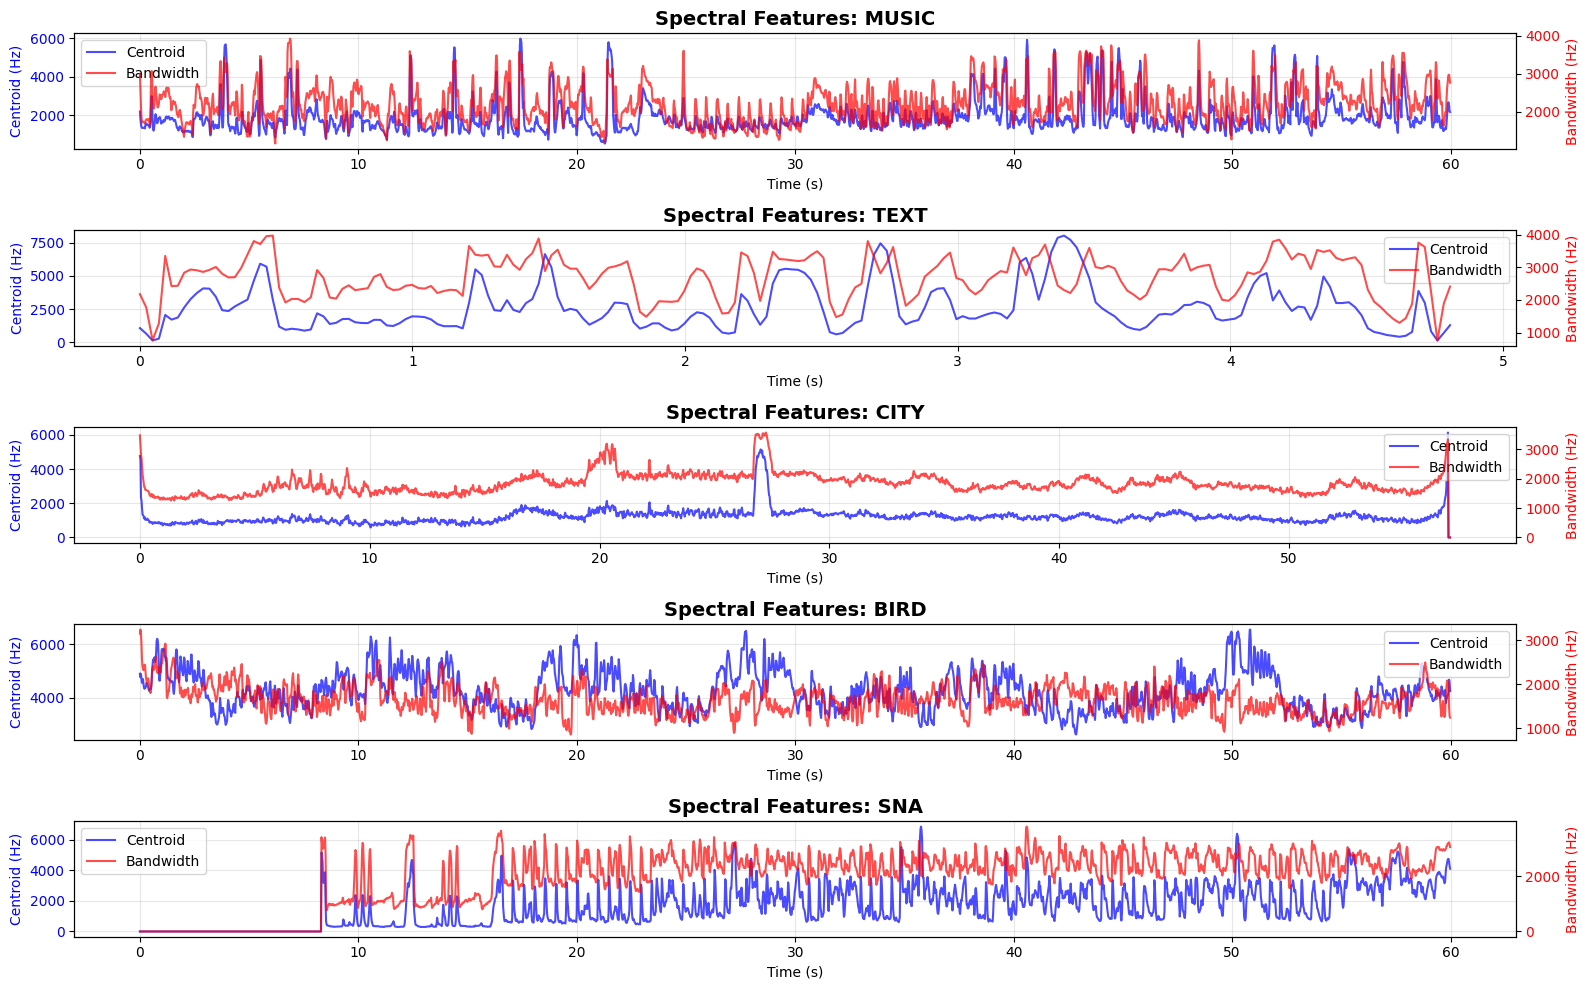

In [114]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, data) in enumerate(spectral_results.items()):
    ax = axes[idx]
    frames = len(data['centroid'])
    time = librosa.frames_to_time(np.arange(frames), sr=22050)
    ax2 = ax.twinx()
    line1 = ax.plot(time, data['centroid'], 'b-', alpha=0.7, label='Centroid')
    line2 = ax2.plot(time, data['bandwidth'], 'r-', alpha=0.7, label='Bandwidth')
    ax.set_title(f'Spectral Features: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Centroid (Hz)', color='b')
    ax2.set_ylabel('Bandwidth (Hz)', color='r')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='r')
    ax.grid(True, alpha=0.3)
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels)
plt.tight_layout()



## 3. RMS Energy

**Теория:** RMS характеризует громкость сигнала.

**Формула:**
$$RMS = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} x_n^2}$$

In [115]:
rms_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    rms_results[name] = analyzer.get_rms()
    print(f"{name}: RMS mean={rms_results[name]['rms_mean']:.4f}")

music: RMS mean=0.2503
text: RMS mean=0.0316
city: RMS mean=0.0600
bird: RMS mean=0.0812
sna: RMS mean=0.1498


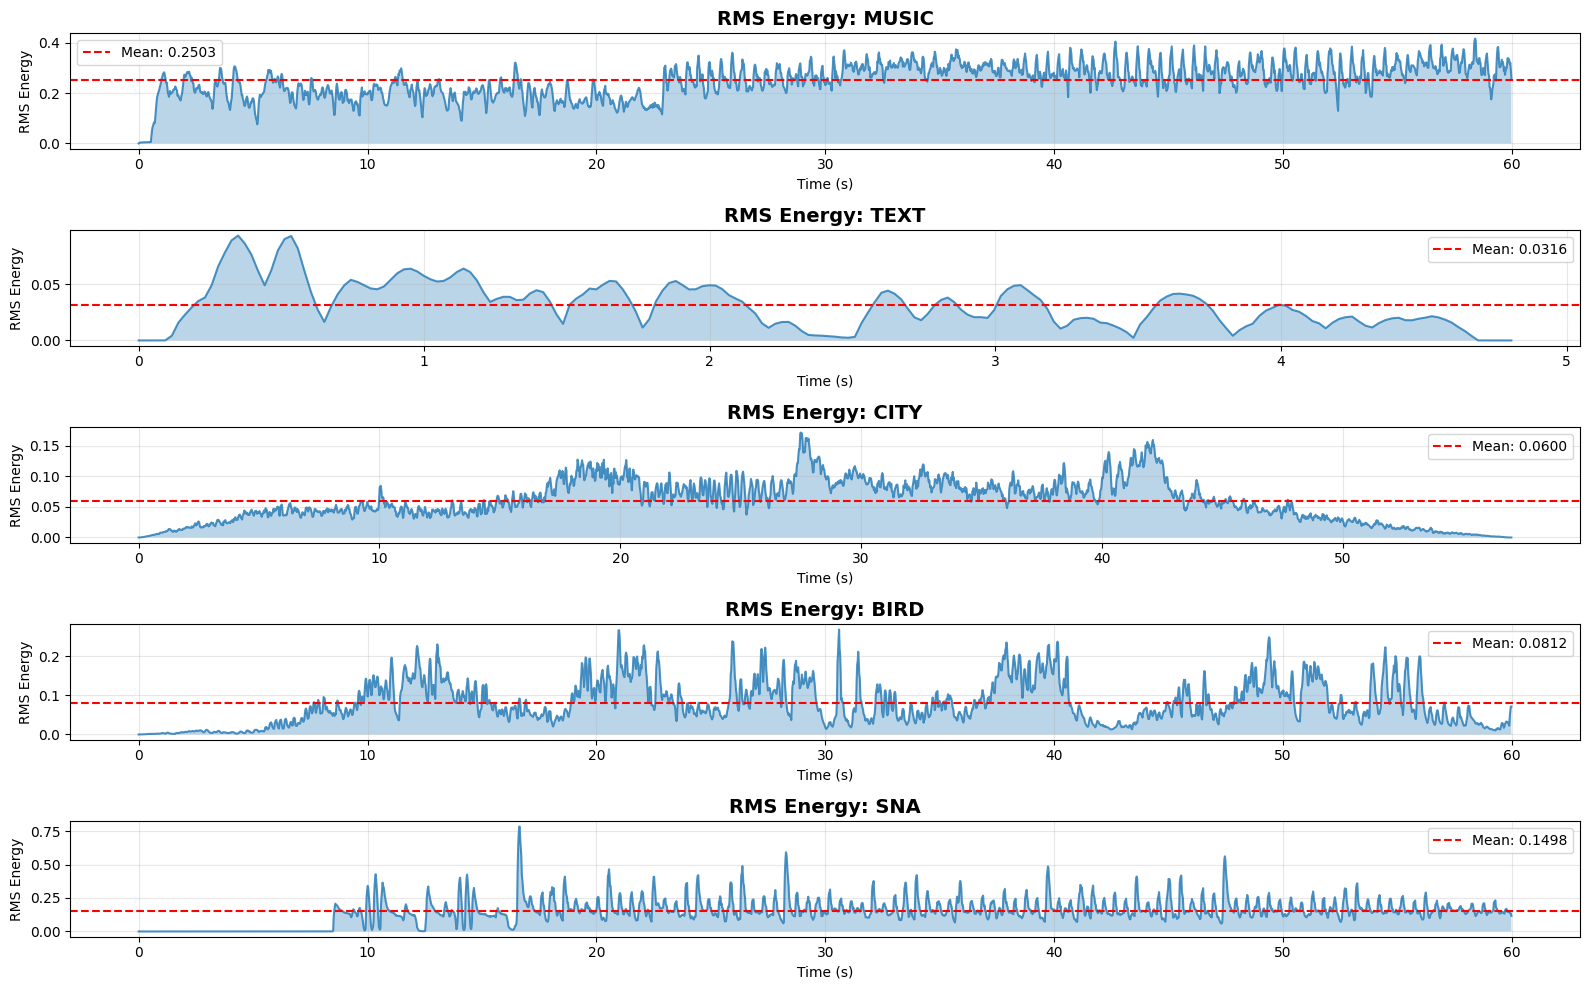

In [116]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, data) in enumerate(rms_results.items()):
    ax = axes[idx]
    frames = len(data['rms'])
    time = librosa.frames_to_time(np.arange(frames), sr=22050)
    ax.plot(time, data['rms'], linewidth=1.5, alpha=0.8)
    ax.fill_between(time, 0, data['rms'], alpha=0.3)
    ax.axhline(data['rms_mean'], color='red', linestyle='--', label=f"Mean: {data['rms_mean']:.4f}")
    ax.set_title(f'RMS Energy: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('RMS Energy')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()


## 4. Zero Crossing Rate (ZCR)

**Теория:** ZCR измеряет частоту пересечения нуля. Высокий ZCR характерен для шумоподобных сигналов.

**Формула:**
$$ZCR = \frac{1}{2N} \sum_{n=1}^{N-1} |\text{sign}(x_n) - \text{sign}(x_{n-1})|$$

In [117]:
zcr_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    zcr_results[name] = analyzer.get_zcr()
    print(f"{name}: ZCR mean={zcr_results[name]['zcr_mean']:.4f}")

music: ZCR mean=0.0751
text: ZCR mean=0.0943
city: ZCR mean=0.0346
bird: ZCR mean=0.3816
sna: ZCR mean=0.0589


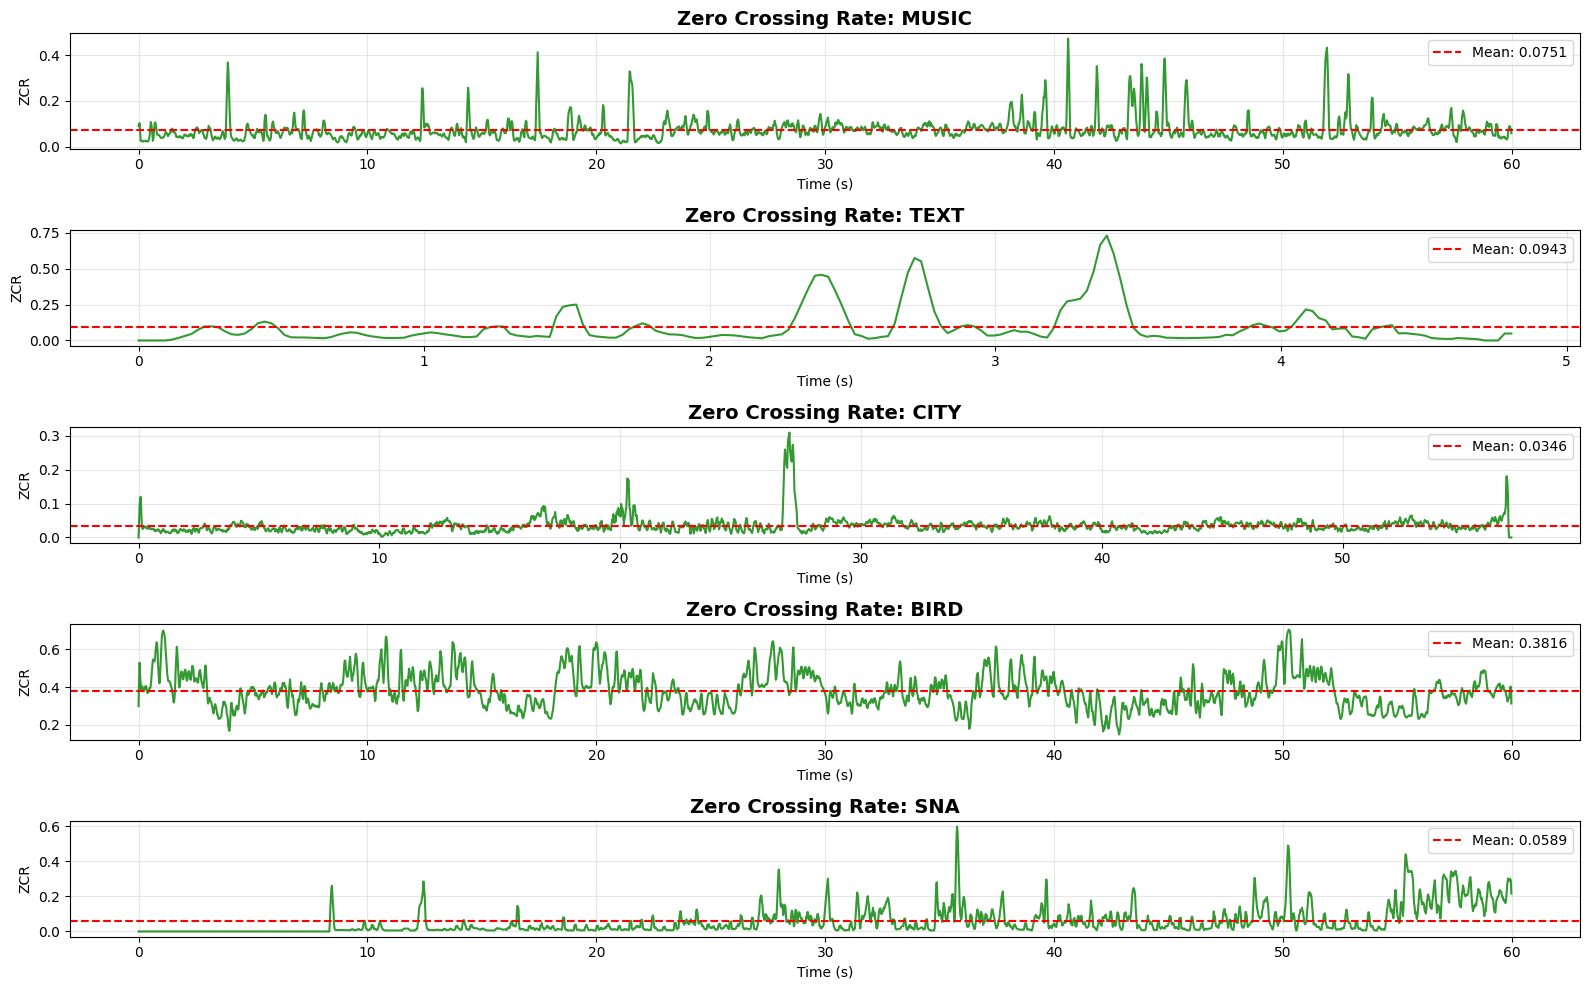

In [118]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, data) in enumerate(zcr_results.items()):
    ax = axes[idx]
    frames = len(data['zcr'])
    time = librosa.frames_to_time(np.arange(frames), sr=22050)
    ax.plot(time, data['zcr'], linewidth=1.5, alpha=0.8, color='green')
    ax.axhline(data['zcr_mean'], color='red', linestyle='--', label=f"Mean: {data['zcr_mean']:.4f}")
    ax.set_title(f'Zero Crossing Rate: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ZCR')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()


## 5. Harmonic-Percussive Separation (HPSS)

**Теория:** HPSS разделяет сигнал на гармоническую (тональную) и перкуссионную (ударную) компоненты.

**Грубо говоря: отделяем мелодию от ударных**

In [119]:
hpss_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    hpss_results[name] = analyzer.get_hpss()
    print(f"{name}: H_energy={hpss_results[name]['harmonic_energy']:.2e}, P_energy={hpss_results[name]['percussive_energy']:.2e}")

music: H_energy=4.99e+04, P_energy=1.93e+04
text: H_energy=8.11e+01, P_energy=3.46e+01
city: H_energy=4.04e+03, P_energy=4.57e+02
bird: H_energy=1.70e+03, P_energy=7.11e+03
sna: H_energy=2.01e+04, P_energy=1.10e+04


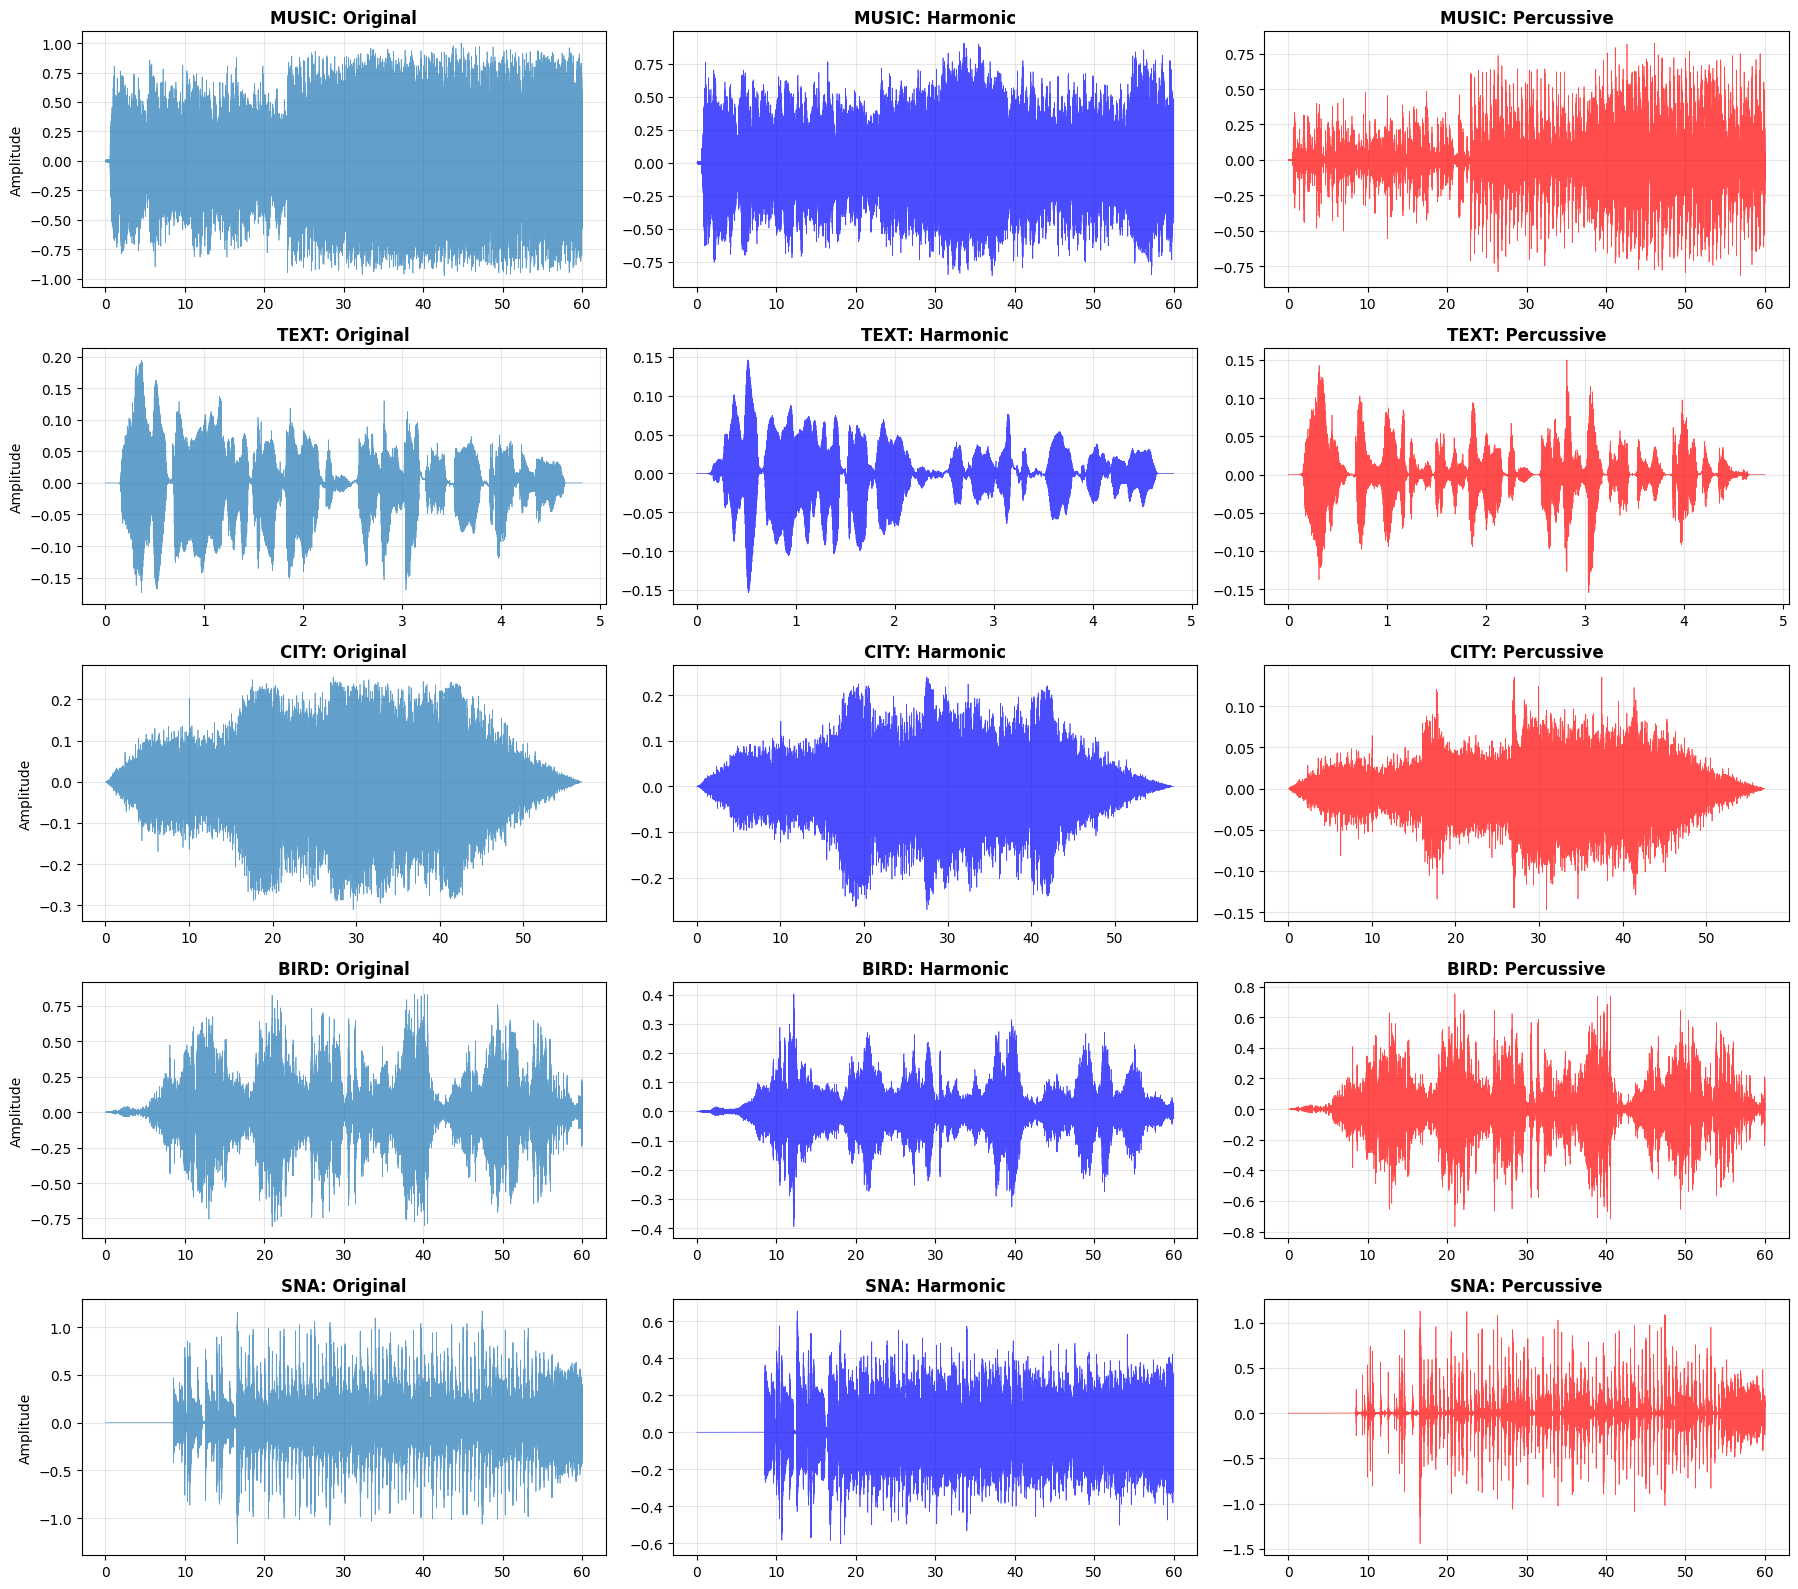

In [120]:

fig, axes = plt.subplots(len(hpss_results), 3, figsize=(18, 16))

for idx, (name, data) in enumerate(hpss_results.items()):
    analyzer = AudioAnalyzer(files[name])
    time = np.linspace(0, len(analyzer.y)/analyzer.sr, len(analyzer.y))
    
    ax_orig = axes[idx, 0]
    ax_orig.plot(time, analyzer.y, linewidth=0.5, alpha=0.7)
    ax_orig.set_title(f'{name.upper()}: Original', fontsize=12, fontweight='bold')
    ax_orig.set_ylabel('Amplitude')
    ax_orig.grid(True, alpha=0.3)
    
    ax_harm = axes[idx, 1]
    time_harm = np.linspace(0, len(data['harmonic'])/analyzer.sr, len(data['harmonic']))
    ax_harm.plot(time_harm, data['harmonic'], linewidth=0.5, alpha=0.7, color='blue')
    ax_harm.set_title(f'{name.upper()}: Harmonic', fontsize=12, fontweight='bold')
    ax_harm.grid(True, alpha=0.3)
    
    ax_perc = axes[idx, 2]
    time_perc = np.linspace(0, len(data['percussive'])/analyzer.sr, len(data['percussive']))
    ax_perc.plot(time_perc, data['percussive'], linewidth=0.5, alpha=0.7, color='red')
    ax_perc.set_title(f'{name.upper()}: Percussive', fontsize=12, fontweight='bold')
    ax_perc.grid(True, alpha=0.3)

plt.tight_layout()



## 6. Mel-Frequency Cepstral Coefficients (MFCC)

**Теория:** MFCC моделируют восприятие звука человеческим ухом.

**Формула:**
$$MFCC = DCT(\log(|STFT|^2 \cdot M))$$

где $M$ — матрица мел-фильтров, $DCT$ — дискретное косинусное преобразование

In [121]:
mfcc_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    mfcc_results[name] = analyzer.get_mfcc(n_mfcc=20)
    print(f"{name}: MFCC shape={mfcc_results[name]['mfccs'].shape}")

music: MFCC shape=(20, 2584)
text: MFCC shape=(20, 208)
city: MFCC shape=(20, 2456)
bird: MFCC shape=(20, 2584)
sna: MFCC shape=(20, 2584)


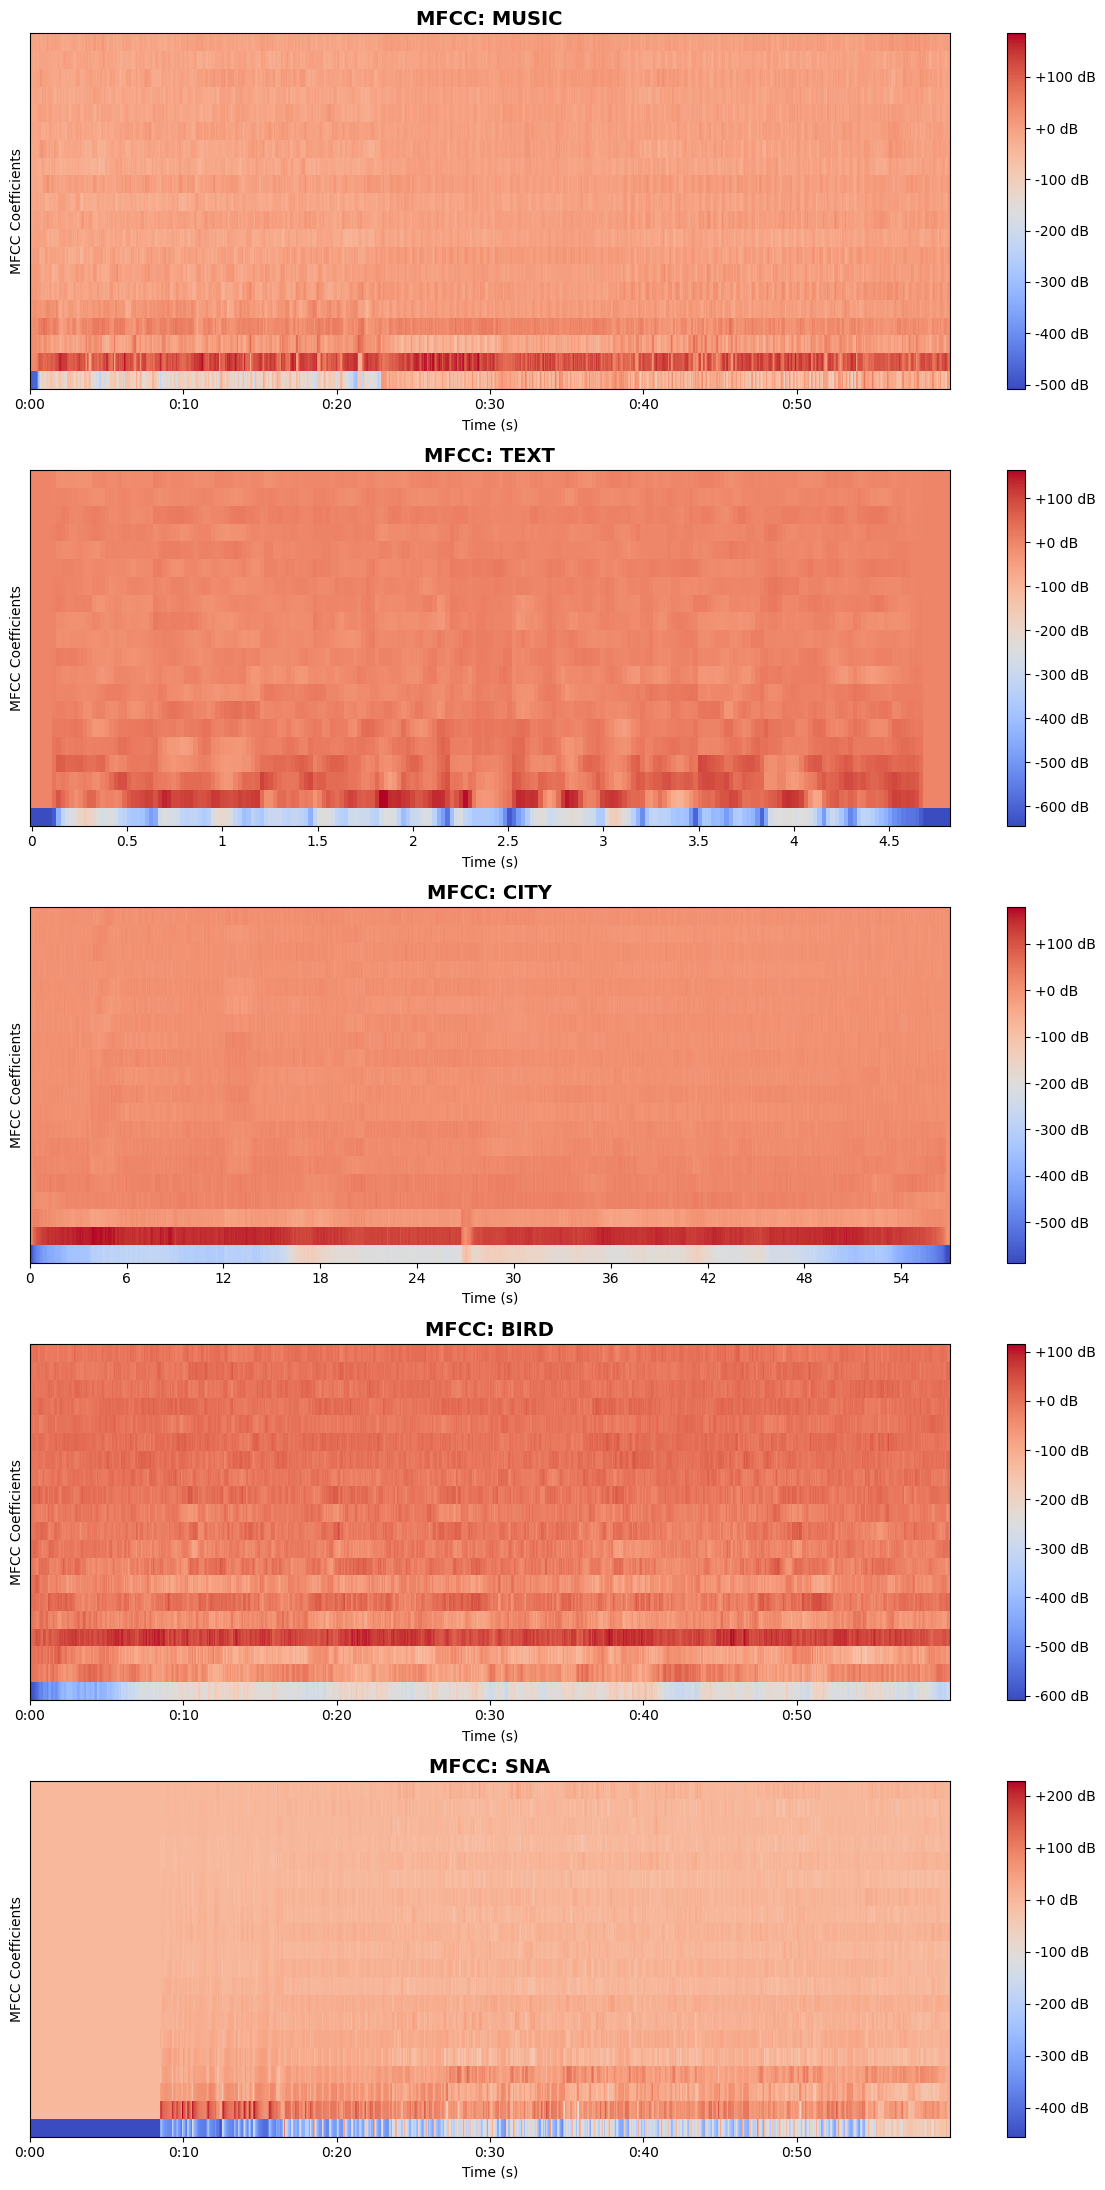

In [122]:
fig, axes = plt.subplots(5, 1, figsize=(12,22 ))
axes = axes.flatten()
for idx, (name, data) in enumerate(mfcc_results.items()):
    ax = axes[idx]
    img = librosa.display.specshow(data['mfccs'], x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(f'MFCC: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('MFCC Coefficients')
    ax.set_xlabel('Time (s)')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()



## 7. Chroma Features

**Теория:** Хроматические признаки отображают энергию 12 нот хроматической гаммы.

**Формула:**
$$C(p) = \sum_{k} |X(k)|^2 \cdot W(k, p)$$

где $p \in \{C, C\#, D, ..., B\}$ — классы высоты тона

In [123]:
chroma_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    chroma_results[name] = analyzer.get_chroma()
    print(f"{name}: Chroma shape={chroma_results[name]['chroma'].shape}")

music: Chroma shape=(12, 2584)
text: Chroma shape=(12, 208)
city: Chroma shape=(12, 2456)
bird: Chroma shape=(12, 2584)
sna: Chroma shape=(12, 2584)


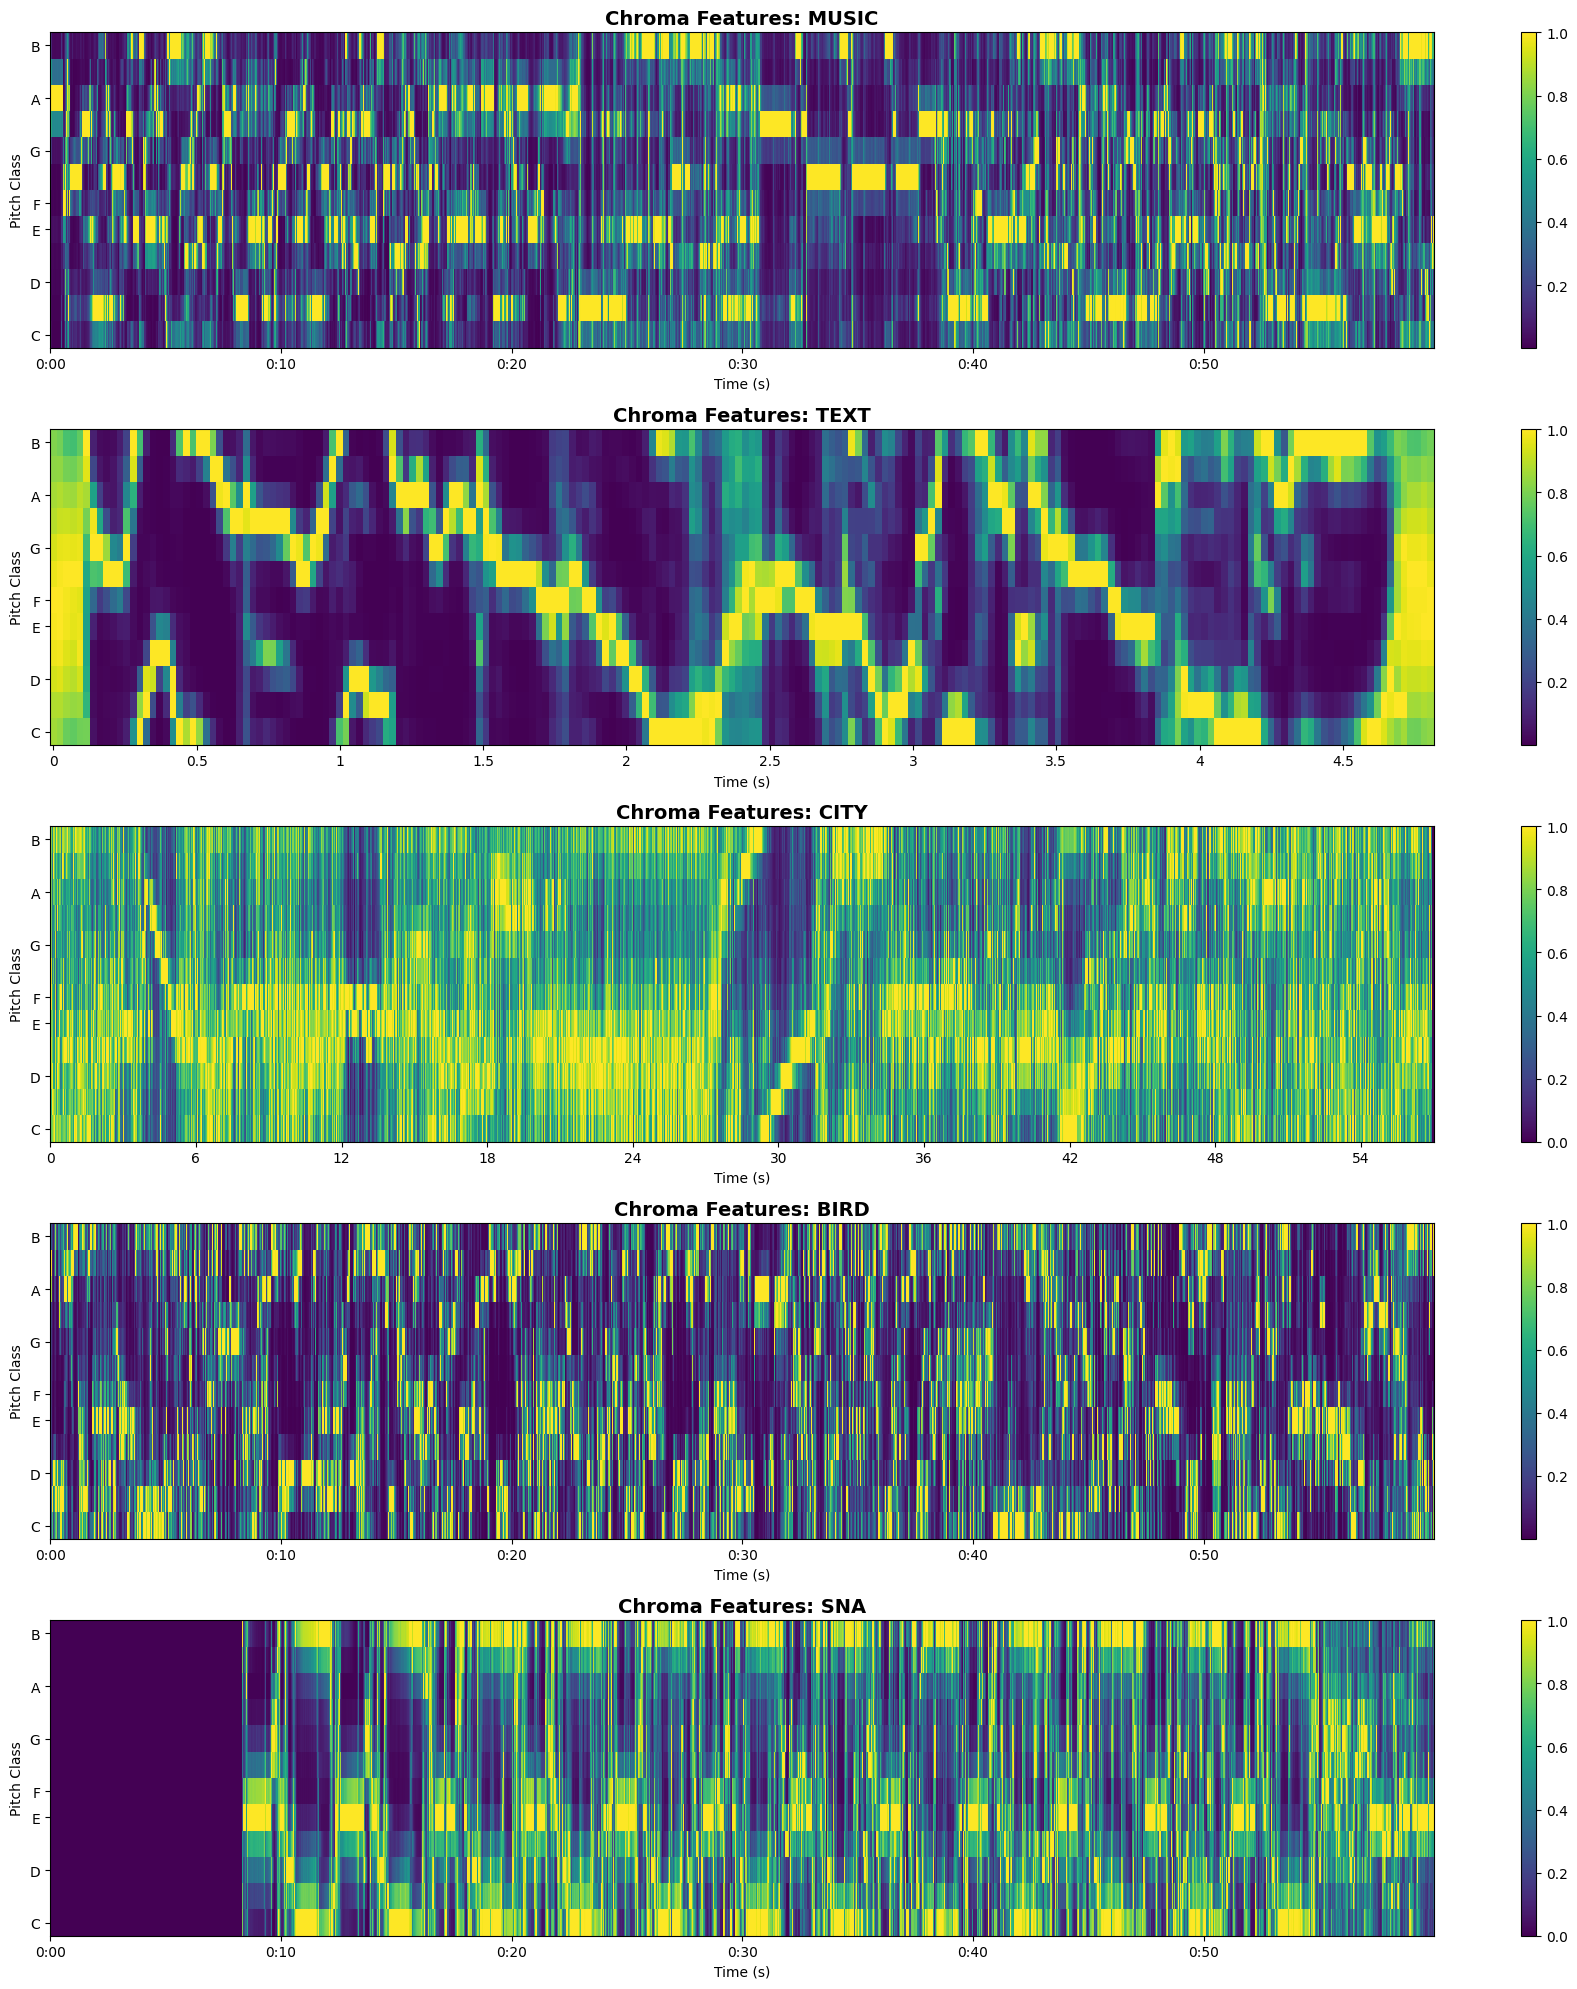

In [124]:
fig, axes = plt.subplots(5, 1, figsize=(18,20))
axes = axes.flatten()
for idx, (name, data) in enumerate(chroma_results.items()):
    ax = axes[idx]
    img = librosa.display.specshow(data['chroma'], y_axis='chroma', x_axis='time', ax=ax, cmap='viridis')
    ax.set_title(f'Chroma Features: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Pitch Class')
    ax.set_xlabel('Time (s)')
    fig.colorbar(img, ax=ax)
plt.tight_layout()



## 8. Spectral Contrast

**Теория:** Спектральный контраст измеряет разницу между пиками и впадинами в спектре.

**Формула:**
$$SC(b) = 10 \log_{10}\left(\frac{P_{peak}(b)}{P_{valley}(b)}\right)$$

In [125]:
contrast_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    contrast_results[name] = analyzer.get_spectral_contrast(n_bands=6)
    print(f"{name}: Spectral Contrast shape={contrast_results[name]['contrast'].shape}")

music: Spectral Contrast shape=(7, 2584)
text: Spectral Contrast shape=(7, 208)
city: Spectral Contrast shape=(7, 2456)
bird: Spectral Contrast shape=(7, 2584)
sna: Spectral Contrast shape=(7, 2584)


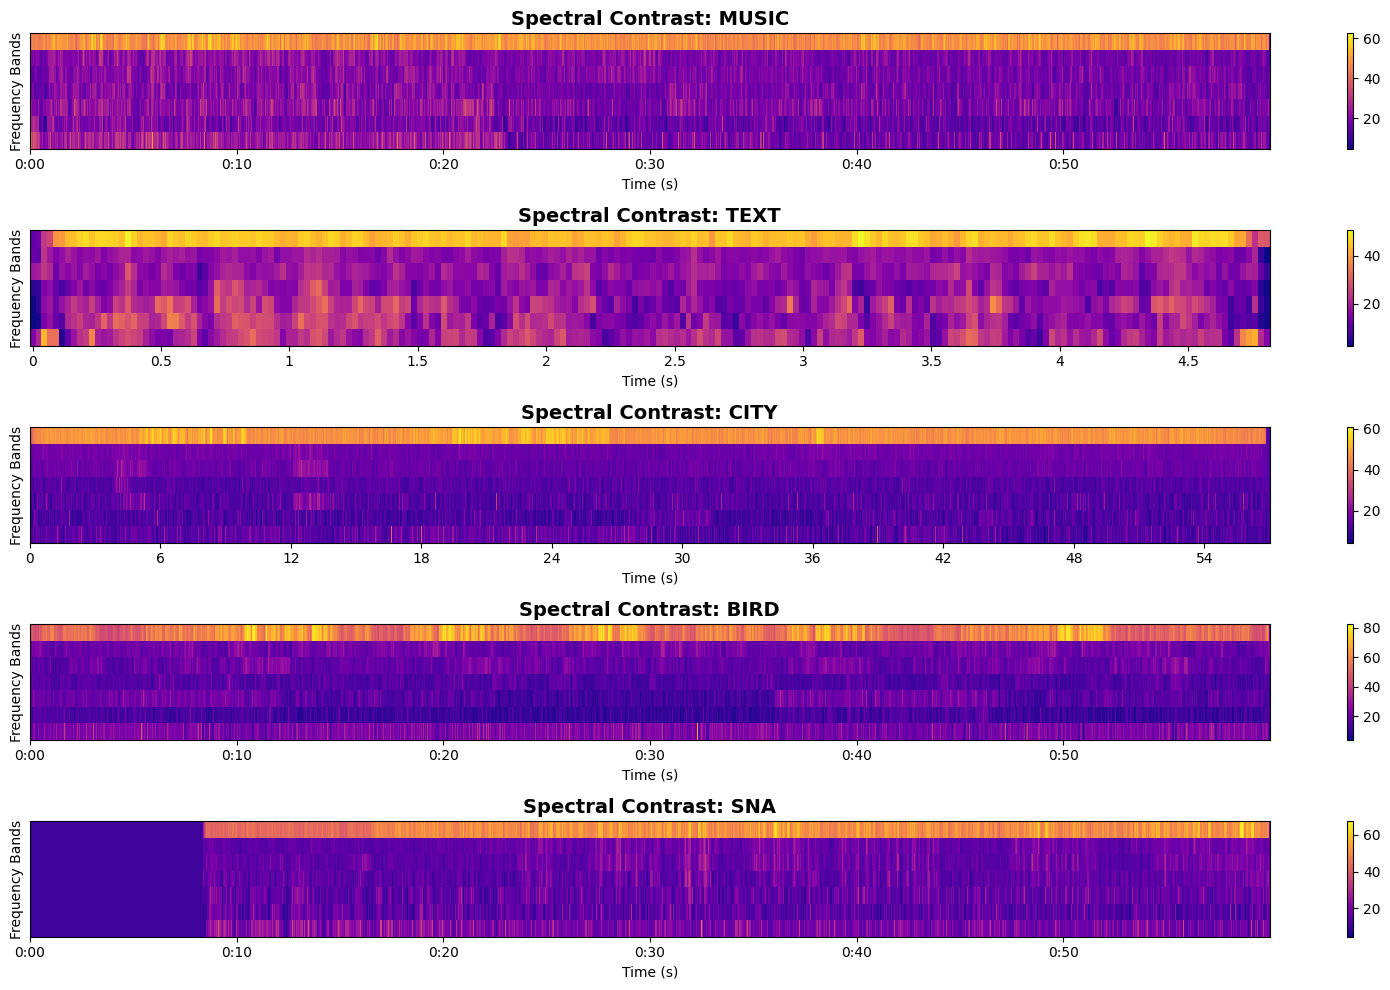

In [126]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10))
axes = axes.flatten()
for idx, (name, data) in enumerate(contrast_results.items()):
    ax = axes[idx]
    img = librosa.display.specshow(data['contrast'], x_axis='time', ax=ax, cmap='plasma')
    ax.set_title(f'Spectral Contrast: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency Bands')
    ax.set_xlabel('Time (s)')
    fig.colorbar(img, ax=ax)
plt.tight_layout()



## 10. Linear Predictive Coding (LPC)

**Теория:** LPC моделирует голосовой тракт, предсказывая текущий отсчет на основе предыдущих.

**Формула:**
$$\hat{x}(n) = \sum_{k=1}^{p} a_k x(n-k)$$

где $a_k$ — коэффициенты предсказания, $p$ — порядок модели

In [127]:
lpc_results = {}
for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    lpc_results[name] = analyzer.get_lpc(order=16)
    print(f"{name}: LPC coefficients shape={lpc_results[name]['coefficients'].shape}")

music: LPC coefficients shape=(17,)
text: LPC coefficients shape=(17,)
city: LPC coefficients shape=(17,)
bird: LPC coefficients shape=(17,)
sna: LPC coefficients shape=(17,)


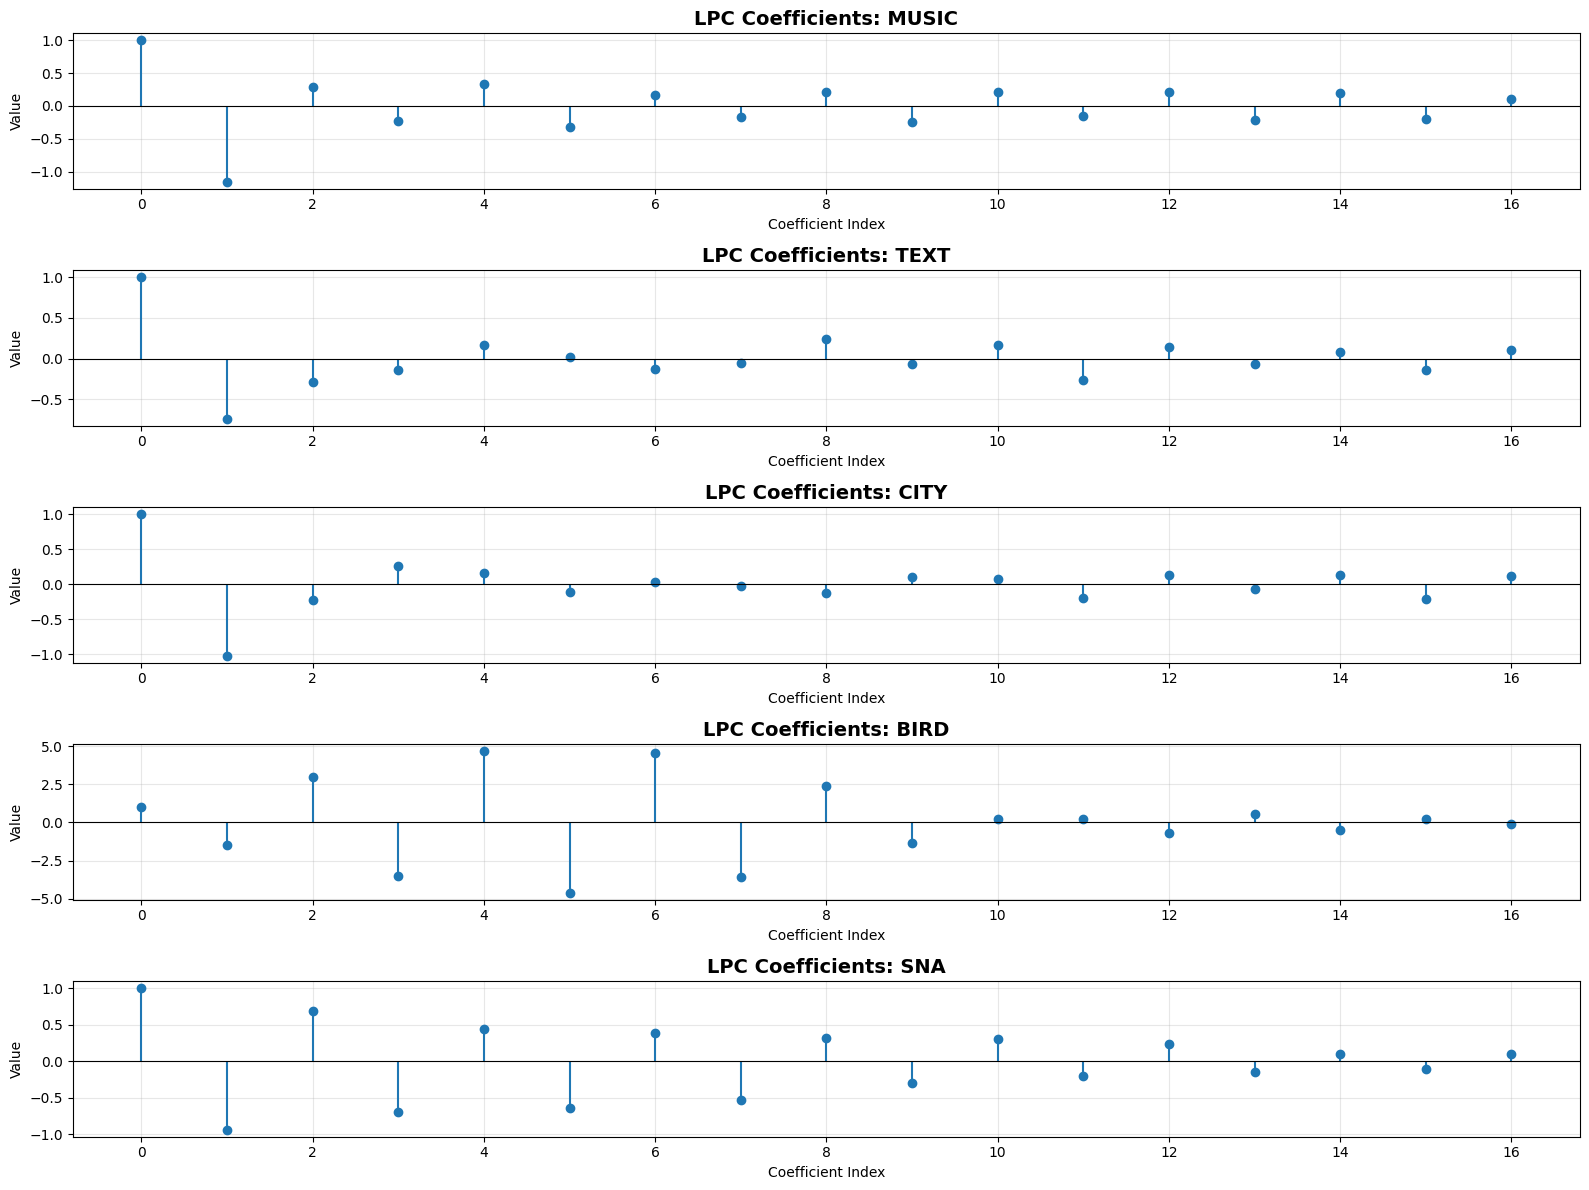

In [128]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12))
axes = axes.flatten()
for idx, (name, data) in enumerate(lpc_results.items()):
    ax = axes[idx]
    coeffs = data['coefficients']
    ax.stem(range(len(coeffs)), coeffs, basefmt=' ')
    ax.set_title(f'LPC Coefficients: {name.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Coefficient Index')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## Собираем все результаты в единый DataFrame.

In [129]:
summary_data = []

for name, path in files.items():
    analyzer = AudioAnalyzer(path)
    row = {'File': name}
    
    fft_data = analyzer.get_fft()
    row['Peak_Frequency_Hz'] = fft_data['peak_freq']
    
    spectral_data = analyzer.get_spectral_features()
    row['Spectral_Centroid_Hz'] = spectral_data['centroid_mean']
    row['Spectral_Bandwidth_Hz'] = spectral_data['bandwidth_mean']
    
    rms_data = analyzer.get_rms()
    row['RMS_Mean'] = rms_data['rms_mean']
    row['RMS_Std'] = rms_data['rms_std']
    
    zcr_data = analyzer.get_zcr()
    row['ZCR_Mean'] = zcr_data['zcr_mean']
    
    hpss_data = analyzer.get_hpss()
    row['Harmonic_Energy'] = hpss_data['harmonic_energy']
    row['Percussive_Energy'] = hpss_data['percussive_energy']
    row['Harmonic_Ratio'] = hpss_data['harmonic_energy'] / (hpss_data['harmonic_energy'] + hpss_data['percussive_energy'])
    
    mfcc_data = analyzer.get_mfcc()
    row['MFCC_1_Mean'] = mfcc_data['mean'][0]
    row['MFCC_2_Mean'] = mfcc_data['mean'][1]
    
    chroma_data = analyzer.get_chroma()
    row['Chroma_Energy'] = np.sum(chroma_data['chroma'])
    
    contrast_data = analyzer.get_spectral_contrast()
    row['Spectral_Contrast_Mean'] = np.mean(contrast_data['contrast_mean'])
    

    
    lpc_data = analyzer.get_lpc()
    row['LPC_Coeff_1'] = lpc_data['coefficients'][1]
    
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(4)

display(df_summary)

,File,Peak_Frequency_Hz,Spectral_Centroid_Hz,Spectral_Bandwidth_Hz,RMS_Mean,RMS_Std,ZCR_Mean,Harmonic_Energy,Percussive_Energy,Harmonic_Ratio,MFCC_1_Mean,MFCC_2_Mean,Chroma_Energy,Spectral_Contrast_Mean,LPC_Coeff_1
0,music,42.7000,1875.3248,2224.5578,0.2503,0.0656,0.0751,49857.261719,19288.845703,0.7210,-67.070396,110.417297,10333.022461,23.4569,-1.1540
1,text,182.4338,2619.4233,2702.8026,0.0316,0.0206,0.0943,81.130402,34.550201,0.7013,-358.714691,56.563099,802.607178,21.9709,-0.7396
2,city,30.1445,1213.8419,1828.1199,0.0600,0.0341,0.0346,4035.492920,457.259186,0.8982,-251.607605,135.204102,18402.669922,18.7707,-1.0235
3,bird,2575.9667,4249.5707,1640.2607,0.0812,0.0555,0.3816,1699.180542,7108.872559,0.1929,-255.520599,-47.871201,10177.289062,23.7921,-1.5041
4,sna,65.6667,1649.7811,1977.9171,0.1498,0.0963,0.0589,20102.078125,11002.277344,0.6463,-219.359299,69.106697,12705.550781,19.9960,-0.9370
